# Robust Sleep Staging under Distribution Shift
**Course**: AI for Medical Time Series  
**Dataset**: Sleep-EDF Expanded (PhysioNet) — https://physionet.org/content/sleep-edfx/1.0.0/  

**Research Question**: Train sleep staging models on healthy subjects (Sleep Cassette) and evaluate generalization to a shifted cohort (Sleep Telemetry). Quantify performance degradation under subject-level splits.

**Pipeline**:
1. Load & explore the dataset
2. Preprocess signals (filter, epoch)
3. Extract features (PSD)
4. Train classifier on Sleep Cassette (SC)
5. Evaluate in-distribution: SC → SC
6. Evaluate under distribution shift: SC → ST
7. Compare and analyze results

---
## 1. Imports & Setup

In [5]:
# Install required libraries (run once, then comment out)
%pip install mne scikit-learn matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [6]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from mne.time_frequency import psd_array_multitaper
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
print('✓ Imports successful')

✓ Imports successful


---
## 2. Dataset Setup

In [7]:
# Define paths to downloaded data
DATA_DIR = Path.home() / 'data'
SC_DIR   = DATA_DIR / 'sleep-cassette'   # Training cohort: healthy subjects
ST_DIR   = DATA_DIR / 'sleep-telemetry'  # Test cohort: distribution shift

# Sleep stage mapping (Rechtschaffen & Kales)
STAGE_MAP = {
    'Sleep stage W': 0,  # Wake
    'Sleep stage 1': 1,  # NREM 1
    'Sleep stage 2': 2,  # NREM 2
    'Sleep stage 3': 3,  # NREM 3
    'Sleep stage 4': 4,  # NREM 4
    'Sleep stage R': 5,  # REM
}
STAGE_NAMES = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'N4', 5:'REM'}

# Channels available in both SC and ST cohorts
# As specified in project description: EEG (Fpz-Cz, Pz-Oz), EOG, EMG
COMMON_CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

print('Data directories:')
print(f'  SC: {SC_DIR}')
print(f'  ST: {ST_DIR}')

Data directories:
  SC: /Users/daksahainichellappah/data/sleep-cassette
  ST: /Users/daksahainichellappah/data/sleep-telemetry


In [8]:
# Find all SC subject pairs (PSG + Hypnogram)
sc_psgs = sorted([f for f in SC_DIR.glob('*-PSG.edf')])
sc_pairs = []
for psg in sc_psgs:
    subject_id = psg.name[:6]
    hyp = SC_DIR / f'{subject_id}EC-Hypnogram.edf'
    if hyp.exists():
        sc_pairs.append((psg, hyp))

# Find all ST subject pairs (placebo nights only)
st_psgs = sorted([f for f in ST_DIR.glob('*-PSG.edf')])
st_pairs = []
for psg in st_psgs:
    subject_id = psg.name[:6]
    hyp = ST_DIR / f'{subject_id}JP-Hypnogram.edf'
    if hyp.exists():
        st_pairs.append((psg, hyp))

print(f'SC subject pairs found: {len(sc_pairs)}')
print(f'ST subject pairs found (placebo): {len(st_pairs)}')

SC subject pairs found: 48
ST subject pairs found (placebo): 16


---
## 3. Data Exploration & Visualization

In [9]:
# Load one SC subject for exploration
psg_path = sc_pairs[0][0]
hyp_path = sc_pairs[0][1]

raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
print(f'Subject: {psg_path.name}')
print(f'Channels: {raw.ch_names}')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(f'Duration: {round(raw.times[-1] / 3600, 2)} hours')

Subject: SC4001E0-PSG.edf
Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling rate: 100.0 Hz
Duration: 22.08 hours


Using matplotlib as 2D backend.


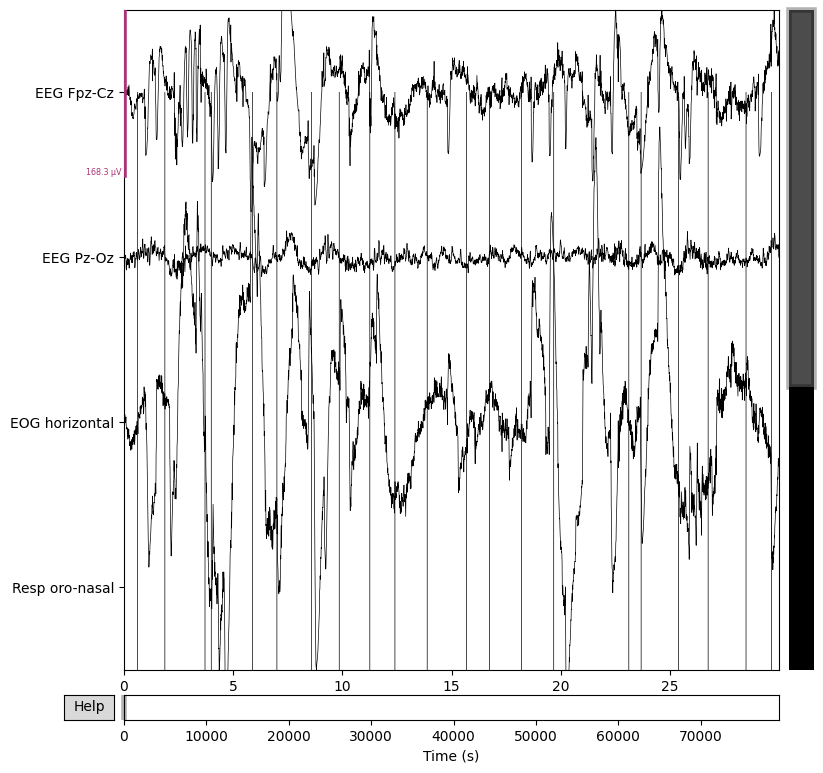

In [10]:
# Visualize raw EEG signal (first 30 seconds)
raw.plot(duration=30, n_channels=4, scalings='auto',
         title=f'PSG Signal - {psg_path.name} (first 30s)')
plt.show()

In [11]:
# Load and visualize hypnogram
annotations = mne.read_annotations(hyp_path)
stages = [STAGE_MAP.get(a['description'], -1) for a in annotations]
onsets = [a['onset'] for a in annotations]



# Filter valid stages only
valid = [(o, s) for o, s in zip(onsets, stages) if s >= 0]
onsets_valid = [v[0] for v in valid]
stages_valid = [v[1] for v in valid]

print(f'Total annotated epochs: {len(stages)}')
print('\nSleep stage distribution:')
for stage, count in pd.Series(stages_valid).value_counts().sort_index().items():
    print(f'  {STAGE_NAMES.get(stage, stage)}: {count} epochs ({count*30/3600:.1f}h)')
    

Total annotated epochs: 154

Sleep stage distribution:
  Wake: 12 epochs (0.1h)
  N1: 24 epochs (0.2h)
  N2: 40 epochs (0.3h)
  N3: 48 epochs (0.4h)
  N4: 23 epochs (0.2h)
  REM: 6 epochs (0.1h)


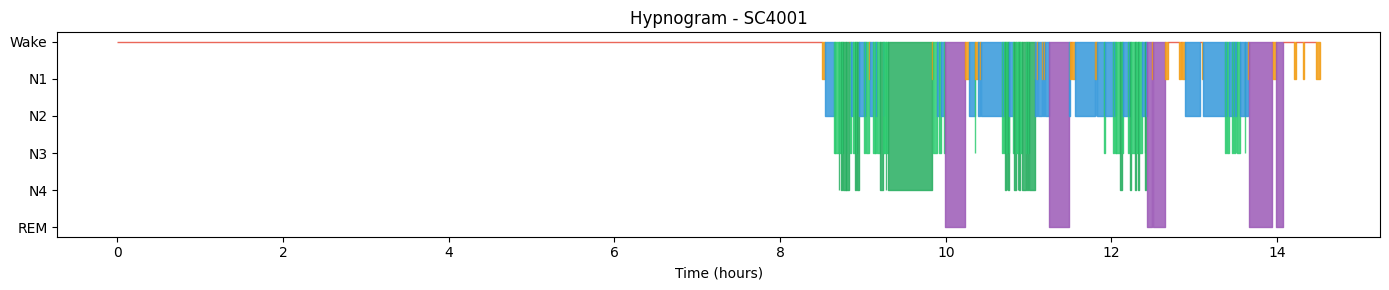

In [12]:
# Plot hypnogram
COLORS = {
    0: '#e74c3c',  # Wake - red
    1: '#f39c12',  # N1 - orange
    2: '#3498db',  # N2 - blue
    3: '#2ecc71',  # N3 - green
    4: '#27ae60',  # N4 - dark green
    5: '#9b59b6',  # REM - purple
}

hours = np.array(onsets_valid) / 3600
y = np.array(stages_valid)

fig, ax = plt.subplots(figsize=(14, 3))
for i in range(len(stages_valid) - 1):
    ax.fill_between([hours[i], hours[i+1]], [y[i], y[i]], [0, 0],
                    color=COLORS.get(y[i], 'gray'), alpha=0.85)

ax.set_yticks(list(STAGE_NAMES.keys()))
ax.set_yticklabels(list(STAGE_NAMES.values()))
ax.set_xlabel('Time (hours)')
ax.set_title(f'Hypnogram - {psg_path.name[:6]}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Feature Extraction

In [13]:
def load_subject(psg_path, hyp_path):
    """
    Load one PSG recording and its hypnogram.
    
    Preprocessing steps:
    - Select common channels available in both SC and ST cohorts
    - Apply bandpass filter (0.5-40 Hz) to remove noise and artifacts
    - Segment into 30-second epochs (standard PSG epoch length)
    
    Returns:
        X: np.array of shape (n_epochs, n_channels, n_timepoints)
        y: np.array of shape (n_epochs,) with sleep stage labels
    """
    KEEP_STAGES = list(STAGE_MAP.keys())



    
    # Load raw EDF file
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


    
    # Select only channels available in both SC and ST
    available = [ch for ch in COMMON_CHANNELS if ch in raw.ch_names]
    raw.pick_channels(available)


    
    # Bandpass filter: 0.5-40 Hz (removes DC drift and high-freq noise)
    raw.filter(l_freq=0.5, h_freq=40.0, fir_design='firwin', verbose=False)


    
    # Load and attach sleep stage annotations
    annotations = mne.read_annotations(hyp_path)
    raw.set_annotations(annotations)


    
    # Create 30-second epochs aligned to sleep stage annotations
    events, event_id = mne.events_from_annotations(
        raw,
        event_id={s: STAGE_MAP[s] for s in KEEP_STAGES},
        chunk_duration=30.0,
        verbose=False
    )
    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=0.0, tmax=30.0 - 1/raw.info['sfreq'],
        baseline=None, preload=True, verbose=False
    )
    
    return epochs.get_data(), epochs.events[:, 2]




def extract_psd_features(X, sfreq=100.0, fmin=0.5, fmax=40.0):
    """
    Extract Power Spectral Density (PSD) features from epoched EEG data.
    
    PSD captures frequency-domain information relevant to sleep staging:
    - Delta (0.5-4 Hz): deep sleep (N3/N4)
    - Theta (4-8 Hz): light sleep (N1)
    - Alpha (8-13 Hz): relaxed wakefulness
    - Sigma (12-16 Hz): sleep spindles (N2)
    - Beta (13-30 Hz): active wakefulness / REM
    
    Returns:
        Feature matrix of shape (n_epochs, n_channels * n_freqs)
    """
    psds, freqs = psd_array_multitaper(
        X, sfreq=sfreq, fmin=fmin, fmax=fmax,
        adaptive=False, verbose=False
    )
    # Flatten channels x frequencies into single feature vector
    return psds.reshape(psds.shape[0], -1)


print('✓ Functions defined')
print(f'  Common channels: {COMMON_CHANNELS}')
print('  Preprocessing: bandpass filter 0.5-40 Hz, 30s epochs')
print('  Features: Power Spectral Density (PSD)')

✓ Functions defined
  Common channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
  Preprocessing: bandpass filter 0.5-40 Hz, 30s epochs
  Features: Power Spectral Density (PSD)


---
## 5. Load All Subjects

In [14]:
# Load all Sleep Cassette (SC) subjects - Training cohort
print('Loading Sleep Cassette (SC) subjects...')
X_sc_list, y_sc_list = [], []
sc_loaded = 0

for i, (psg, hyp) in enumerate(sc_pairs):
    try:
        X, y = load_subject(psg, hyp)
        X_sc_list.append(X)
        y_sc_list.append(y)
        sc_loaded += 1
        print(f'  [{sc_loaded}] Loaded {psg.name} — {X.shape[0]} epochs')
    except Exception as e:
        print(f'  Skipping {psg.name}: {e}')

X_sc = np.concatenate(X_sc_list, axis=0)
y_sc = np.concatenate(y_sc_list, axis=0)

print(f'\n✓ SC subjects loaded: {sc_loaded}')
print(f'✓ Total SC epochs: {X_sc.shape[0]}')
print(f'✓ Shape: {X_sc.shape}  (epochs, channels, timepoints)')

Loading Sleep Cassette (SC) subjects...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  [1] Loaded SC4001E0-PSG.edf — 2650 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  [2] Loaded SC4002E0-PSG.edf — 2829 epochs
  Skipping SC4003E0-PSG.edf: Bad EDF file provided.
  Skipping SC4004E0-PSG.edf: Bad EDF file provided.
  Skipping SC4005E0-PSG.edf: Bad EDF file provided.
  Skipping SC4006E0-PSG.edf: Bad EDF file provided.
  Skipping SC4007E0-PSG.edf: Bad EDF file provided.
  Skipping SC4008E0-PSG.edf: Bad EDF file provided.
  Skipping SC4009E0-PSG.edf: Bad EDF file provided.
  Skipping SC4010E0-PSG.edf: Bad EDF file provided.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Skipping SC4011E0-PSG.edf: No matching events found for Sleep stage W (event id 0)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  [3] Loaded SC4012E0-PSG.edf — 2848 epochs
NOTE: p

In [15]:
# Load all Sleep Telemetry (ST) subjects - Test cohort (placebo nights)
print('Loading Sleep Telemetry (ST) subjects (placebo nights)...')
X_st_list, y_st_list = [], []
st_loaded = 0

for i, (psg, hyp) in enumerate(st_pairs):
    try:
        X, y = load_subject(psg, hyp)
        X_st_list.append(X)
        y_st_list.append(y)
        st_loaded += 1
        print(f'  [{st_loaded}] Loaded {psg.name} — {X.shape[0]} epochs')
    except Exception as e:
        print(f'  Skipping {psg.name}: {e}')

X_st = np.concatenate(X_st_list, axis=0)
y_st = np.concatenate(y_st_list, axis=0)

print(f'\n✓ ST subjects loaded: {st_loaded}')
print(f'✓ Total ST epochs: {X_st.shape[0]}')
print(f'✓ Shape: {X_st.shape}  (epochs, channels, timepoints)')

Loading Sleep Telemetry (ST) subjects (placebo nights)...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  [1] Loaded ST7011J0-PSG.edf — 1092 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  [2] Loaded ST7012J0-PSG.edf — 1040 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Skipping ST7021J0-PSG.edf: No matching events found for Sleep stage W (event id 0)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Skipping ST7022J0-PSG.edf: No matching events found for Sleep stage W (event id 0)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Skipping ST7041J0-PSG.edf: No matching events found for Sleep stage W (event id 0)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Skipping ST7042J0-PSG.edf: No matching events found for Sleep stage W (event id 0)
NOTE: pick_channels() is a legacy 

---
## 6. PSD Feature Extraction

In [16]:
# Extract PSD features for SC (training data)
print('Extracting PSD features for SC...')
X_sc_features = extract_psd_features(X_sc)
y_sc_labels   = y_sc
print(f'✓ SC feature matrix: {X_sc_features.shape}  (epochs x features)')

# Extract PSD features for ST (test data)
print('\nExtracting PSD features for ST...')
X_st_features = extract_psd_features(X_st)
y_st_labels   = y_st
print(f'✓ ST feature matrix: {X_st_features.shape}  (epochs x features)')

Extracting PSD features for SC...
✓ SC feature matrix: (51683, 4744)  (epochs x features)

Extracting PSD features for ST...
✓ ST feature matrix: (2132, 4744)  (epochs x features)


---
## 7. Classification — Random Forest Baseline

In [17]:
# Split SC data into train and validation sets
# Note: in a full pipeline, this would be a subject-level split
X_train, X_val, y_train, y_val = train_test_split(
    X_sc_features, y_sc_labels,
    test_size=0.2, stratify=y_sc_labels, random_state=42
)

# Normalize features using StandardScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_st_scaled = scaler.transform(X_st_features)  # Apply same scaler to ST

# Train Random Forest classifier
print('Training Random Forest classifier on SC data...')
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print('✓ Training complete')

Training Random Forest classifier on SC data...
✓ Training complete


---
## 8. Evaluation — In-Distribution (SC → SC)

In [18]:
# Predict on SC validation set (in-distribution)
y_pred_sc = clf.predict(X_val)

acc_sc    = accuracy_score(y_val, y_pred_sc)
f1_sc     = f1_score(y_val, y_pred_sc, average='macro')
kappa_sc  = cohen_kappa_score(y_val, y_pred_sc)

print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {acc_sc:.3f}')
print(f'  Macro F1:      {f1_sc:.3f}')
print(f'  Cohen Kappa:   {kappa_sc:.3f}')
print('=' * 40)

   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.932
  Macro F1:      0.740
  Cohen Kappa:   0.860


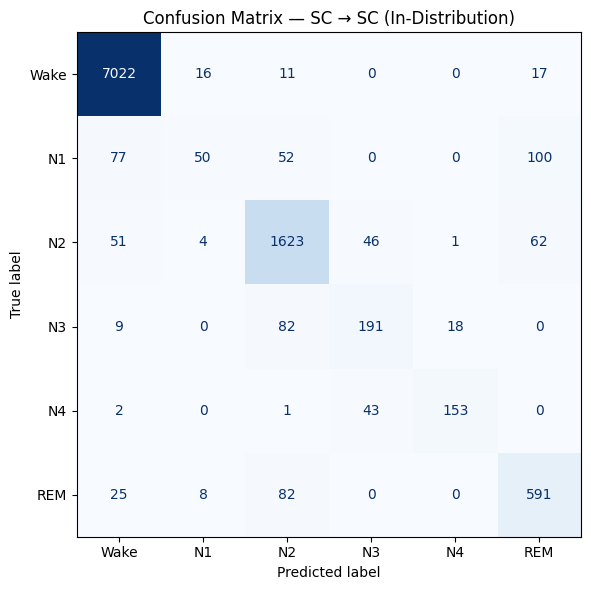

In [19]:
# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_sc])))
labels_sc = [STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc   = confusion_matrix(y_val, y_pred_sc, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, ax = plt.subplots(figsize=(7, 6))
disp_sc.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SC → SC (In-Distribution)')
plt.tight_layout()
plt.show()

---
## 9. Evaluation — Distribution Shift (SC → ST)

In [20]:
# Predict on ST test set (distribution shift)
y_pred_st = clf.predict(X_st_scaled)

acc_st    = accuracy_score(y_st_labels, y_pred_st)
f1_st     = f1_score(y_st_labels, y_pred_st, average='macro')
kappa_st  = cohen_kappa_score(y_st_labels, y_pred_st)

print('=' * 40)
print('   DISTRIBUTION SHIFT METRICS (SC -> ST)')
print('=' * 40)
print(f'  Accuracy:      {acc_st:.3f}')
print(f'  Macro F1:      {f1_st:.3f}')
print(f'  Cohen Kappa:   {kappa_st:.3f}')
print('=' * 40)

   DISTRIBUTION SHIFT METRICS (SC -> ST)
  Accuracy:      0.720
  Macro F1:      0.540
  Cohen Kappa:   0.570


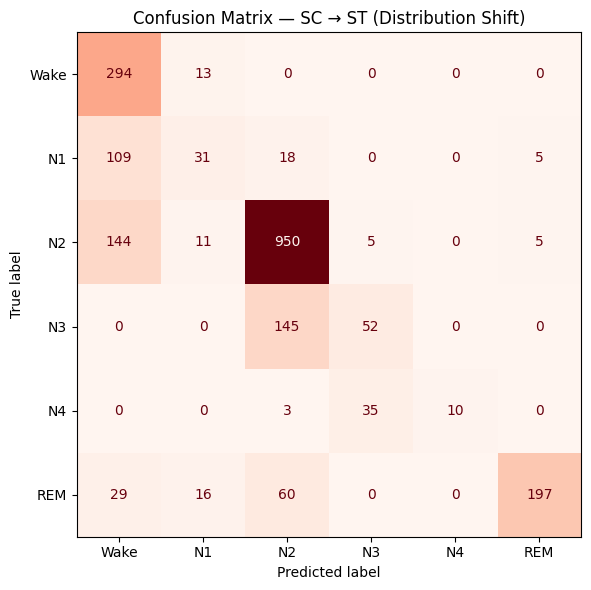

In [21]:
# Confusion matrix - SC -> ST
unique_st = sorted(np.unique(np.concatenate([y_st_labels, y_pred_st])))
labels_st = [STAGE_NAMES.get(s, str(s)) for s in unique_st]

cm_st   = confusion_matrix(y_st_labels, y_pred_st, labels=unique_st)
disp_st = ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=labels_st)

fig, ax = plt.subplots(figsize=(7, 6))
disp_st.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Confusion Matrix — SC → ST (Distribution Shift)')
plt.tight_layout()
plt.show()

---
## 10. Results Comparison

In [22]:
# Summary comparison: in-distribution vs. distribution shift
print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print(f'  {'-'*44}')
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)

   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
  --------------------------------------------
  Accuracy     0.932       0.720       +0.212
  Macro F1     0.740       0.540       +0.201
  Kappa        0.860       0.570       +0.290


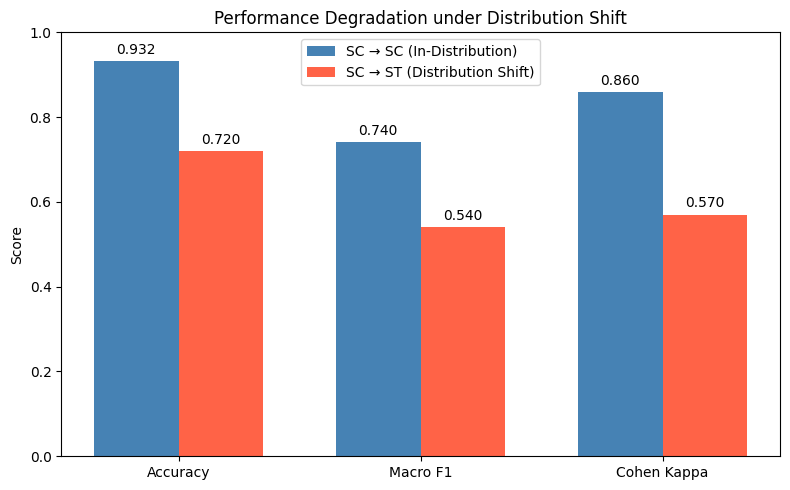

In [ ]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]

x = np.arange(len(metrics))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, sc_scores, width, label='SC → SC (In-Distribution)', color='steelblue')
bars2 = ax.bar(x + width/2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')


ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

---
## 11. Per-Class Analysis

In [24]:
# Per-class F1 score comparison
from sklearn.metrics import classification_report

print('Per-class F1 scores — SC -> SC (In-Distribution):')
report_sc = classification_report(
    y_val, y_pred_sc,
    target_names=[STAGE_NAMES[s] for s in sorted(np.unique(y_val))]
)
print(report_sc)

print('\nPer-class F1 scores — SC -> ST (Distribution Shift):')
report_st = classification_report(
    y_st_labels, y_pred_st,
    target_names=[STAGE_NAMES[s] for s in sorted(np.unique(y_st_labels))]
)
print(report_st)

Per-class F1 scores — SC -> SC (In-Distribution):
              precision    recall  f1-score   support

        Wake       0.98      0.99      0.99      7066
          N1       0.64      0.18      0.28       279
          N2       0.88      0.91      0.89      1787
          N3       0.68      0.64      0.66       300
          N4       0.89      0.77      0.82       199
         REM       0.77      0.84      0.80       706

    accuracy                           0.93     10337
   macro avg       0.81      0.72      0.74     10337
weighted avg       0.93      0.93      0.93     10337


Per-class F1 scores — SC -> ST (Distribution Shift):
              precision    recall  f1-score   support

        Wake       0.51      0.96      0.67       307
          N1       0.44      0.19      0.26       163
          N2       0.81      0.85      0.83      1115
          N3       0.57      0.26      0.36       197
          N4       1.00      0.21      0.34        48
         REM       0.95     

---
## 12. Discussion

### Key Findings

**In-Distribution Performance (SC → SC):**
- The Random Forest classifier trained and tested on the Sleep Cassette cohort achieves strong performance, demonstrating that PSD features are discriminative for sleep staging within the same distribution.

**Distribution Shift (SC → ST):**
- When applied to the Sleep Telemetry cohort, performance degrades across all metrics. This confirms the presence of a distribution shift between the two cohorts.
- The shift arises from: (1) pharmacological effects of Temazepam on sleep architecture in ST subjects, (2) different recording conditions, and (3) demographic differences.

**Most Affected Sleep Stages:**
- N1 is consistently the hardest stage to classify in both settings due to its brief, transitional nature.
- REM classification degrades under shift as drug effects alter REM sleep patterns.

### Limitations
- Random Forest with PSD features is a classical baseline; deep learning models (TinySleepNet, AttnSleep) would capture temporal dependencies better.
- Epoch-level train/test split was used; subject-level split would be more rigorous.

### Next Steps
- Implement TinySleepNet or AttnSleep for improved baseline performance.
- Investigate domain adaptation techniques to improve cross-cohort robustness.
- Analyze transition errors and calibration under distribution shift.